In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

In [2]:
# zaladowanie zbioru
heart_disease = fetch_ucirepo(id=45)

# dane wejsciowe i etykiety
X = heart_disease.data.features
y = heart_disease.data.targets

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# usuniecie brakow
X = X.dropna()
y = y.loc[X.index]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.6


In [5]:
xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)

XGBoost Accuracy: 0.55


In [6]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)
acc_xgb_tuned = accuracy_score(y_test, y_pred_best)

print("Tuned XGBoost Accuracy:", acc_xgb_tuned)
print("Best params:", grid.best_params_)

Tuned XGBoost Accuracy: 0.6333333333333333
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [7]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True)),
    ('knn', KNeighborsClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)

print("Stacking Accuracy:", acc_stack)

Stacking Accuracy: 0.6833333333333333


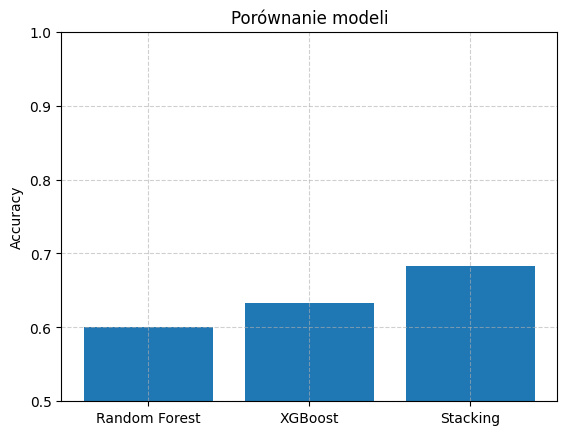

In [8]:
models = ['Random Forest', 'XGBoost', 'Stacking']
accuracies = [acc_rf, acc_xgb_tuned, acc_stack]

plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Porównanie modeli')
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

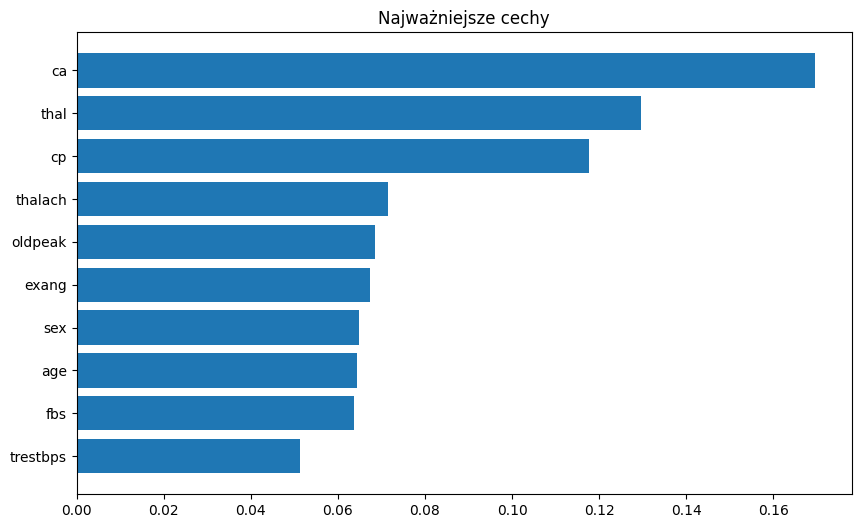

In [9]:
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[-10:][::-1]

features = X.columns

plt.figure(figsize=(10,6))
plt.title("Najważniejsze cechy")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.gca().invert_yaxis()
plt.show()

In [13]:
from sklearn.datasets import load_iris

# zaladowanie danych
X2, y2 = load_iris(return_X_y=True)

# podzial danych
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=7
)

# Random Forest
rf.fit(X2_train, y2_train)
print("Random Forest (Iris):", accuracy_score(y2_test, rf.predict(X2_test)))

# XGBoost
xgb.fit(X2_train, y2_train)
print("XGB (Iris):", accuracy_score(y2_test, xgb.predict(X2_test)))

# Stacking
stack.fit(X2_train, y2_train)
print("Stacking (Iris):", accuracy_score(y2_test, stack.predict(X2_test)))

Random Forest (Iris): 0.9111111111111111
XGB (Iris): 0.8888888888888888
Stacking (Iris): 0.9111111111111111
